# 👩‍💻 Experiment with Regularization Techniques for Neural Networks

## 📋 Overview
In this lab, you'll apply and evaluate various regularization techniques to improve a neural network's performance on image data. You will work with a baseline model and progressively enhance it using dropout, L2 weight decay, and batch normalization. These techniques are essential for preventing overfitting and ensuring your models generalize well to unseen data - critical skills for any machine learning practitioner.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- 1. Device Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 2. Data Loading and Preprocessing ---
# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard normalization for MNIST
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

Using device: cuda


## Task 1: Create and Train a Baseline Model
**Context:** As a first step in understanding the effects of regularization, you need to establish a baseline model to serve as a reference point for comparison.

**Steps:**

1. Define a simple CNN model class with convolutional layers followed by fully connected layers

    - Use `nn.Conv2d` for convolutional layers with appropriate kernel sizes
    - Add `nn.ReLU` activations after each layer
    - Include fully connected layers using `nn.Linear`
    - What architecture complexity is appropriate for this task?

2. Instantiate the baseline model, loss function, and optimizer

    - Use `CrossEntropyLoss()` for classification tasks
    - Consider using `optim.SGD` or `ptim.Adam` for optimization
    - What learning rate would be appropriate?

3. Train the model and evaluate performance

    - Use the provided `train()` and `evaluate()` functions
    - Save the training and testing metrics for comparison

4. Plot the training and validation loss curves

    - How can you determine if the model is overfitting?

Epoch 1/10 | Train Loss: 0.1532 | Train Acc: 95.48% | Val Loss: 0.0448 | Val Acc: 98.56%
Epoch 2/10 | Train Loss: 0.0451 | Train Acc: 98.61% | Val Loss: 0.0354 | Val Acc: 98.77%
Epoch 3/10 | Train Loss: 0.0305 | Train Acc: 99.02% | Val Loss: 0.0290 | Val Acc: 99.07%
Epoch 4/10 | Train Loss: 0.0224 | Train Acc: 99.32% | Val Loss: 0.0299 | Val Acc: 98.97%
Epoch 5/10 | Train Loss: 0.0167 | Train Acc: 99.45% | Val Loss: 0.0313 | Val Acc: 99.07%
Epoch 6/10 | Train Loss: 0.0119 | Train Acc: 99.61% | Val Loss: 0.0322 | Val Acc: 99.15%
Epoch 7/10 | Train Loss: 0.0101 | Train Acc: 99.67% | Val Loss: 0.0518 | Val Acc: 98.81%
Epoch 8/10 | Train Loss: 0.0097 | Train Acc: 99.70% | Val Loss: 0.0313 | Val Acc: 99.15%
Epoch 9/10 | Train Loss: 0.0075 | Train Acc: 99.74% | Val Loss: 0.0334 | Val Acc: 99.17%
Epoch 10/10 | Train Loss: 0.0072 | Train Acc: 99.76% | Val Loss: 0.0377 | Val Acc: 99.21%


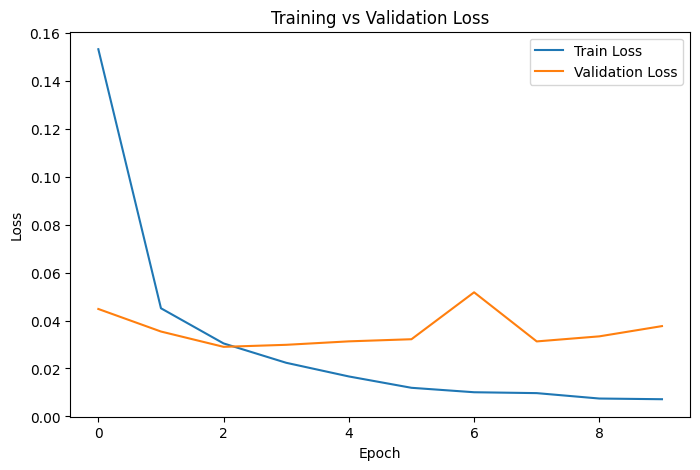

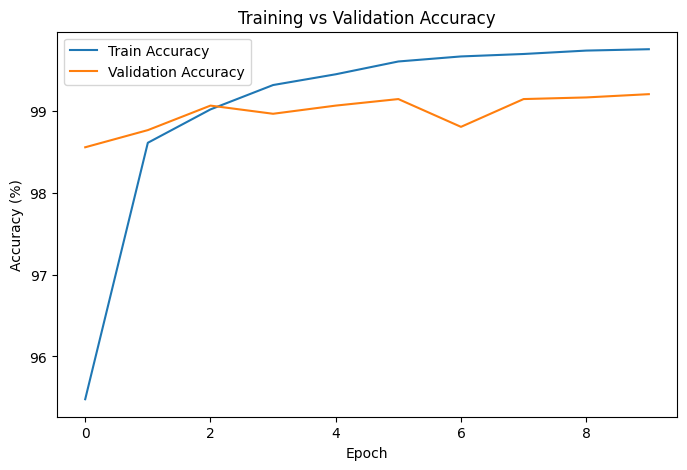

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -----------------------------
# 1. Dataset & DataLoaders
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_dataset   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

# -----------------------------
# 2. Baseline CNN Model
# -----------------------------
class BaselineModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# -----------------------------
# 3. Instantiate Model, Loss, Optimizer
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = BaselineModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 4. Training & Evaluation Loops
# -----------------------------
def train(model, dataloader, criterion, optimizer, device="cpu"):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device="cpu"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# -----------------------------
# 5. Training Loop
# -----------------------------
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# -----------------------------
# 6. Plot Loss Curves
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# -----------------------------
# 7. Plot Accuracy Curves
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## Task 2: Implement Dropout
**Context:** Dropout is a powerful technique that prevents co-adaptation of neurons by randomly setting a fraction of inputs to zero during training, which helps reduce overfitting.

**Steps:**

1. Create a new model class that incorporates dropout layers

    - Add `nn.Dropout` layers after fully connected layers
    - Try a moderate dropout rate (0.2-0.5)
    - How might placement of dropout layers affect model performance?

2. Train the model with dropout and evaluate
    
    - Use the same training parameters as the baseline for fair comparison
    - Pay attention to differences in training time and convergence

3. Compare the dropout model's performance with the baseline

    - Are there notable differences in train vs test loss curves?
    - How does dropout affect the gap between training and validation performance?

[Dropout] Epoch 1/5 | Train Loss: 0.2483 | Train Acc: 92.44% | Val Loss: 0.0515 | Val Acc: 98.23%
[Dropout] Epoch 2/5 | Train Loss: 0.0952 | Train Acc: 97.19% | Val Loss: 0.0400 | Val Acc: 98.65%
[Dropout] Epoch 3/5 | Train Loss: 0.0736 | Train Acc: 97.78% | Val Loss: 0.0302 | Val Acc: 99.03%
[Dropout] Epoch 4/5 | Train Loss: 0.0610 | Train Acc: 98.17% | Val Loss: 0.0285 | Val Acc: 99.07%
[Dropout] Epoch 5/5 | Train Loss: 0.0530 | Train Acc: 98.38% | Val Loss: 0.0322 | Val Acc: 99.05%


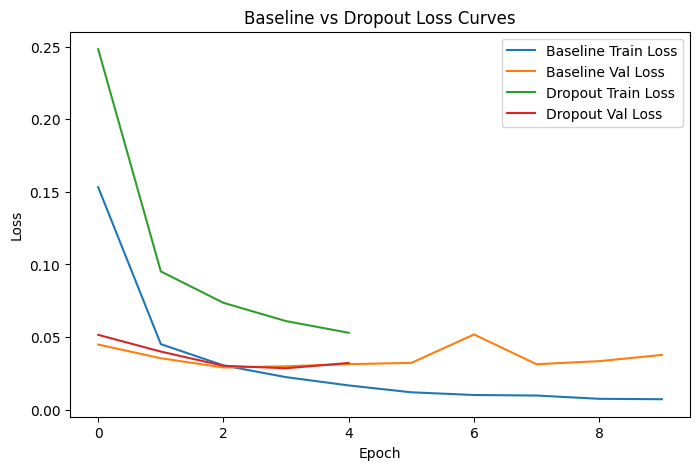

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropoutModel(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super().__init__()

        # Convolutional layers (same as baseline)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers + dropout
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)   # Dropout applied here
        x = self.fc2(x)
        return x

# Instantiate dropout model, define loss function and optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"

dropout_model = DropoutModel(num_classes=10, dropout_rate=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(dropout_model.parameters(), lr=1e-3)

# Train the model and track metrics
num_epochs = 5
train_losses_d, val_losses_d = [], []
train_accs_d, val_accs_d = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(dropout_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(dropout_model, val_loader, criterion, device)

    train_losses_d.append(train_loss)
    val_losses_d.append(val_loss)
    train_accs_d.append(train_acc)
    val_accs_d.append(val_acc)

    print(f"[Dropout] Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Baseline Train Loss")
plt.plot(val_losses, label="Baseline Val Loss")
plt.plot(train_losses_d, label="Dropout Train Loss")
plt.plot(val_losses_d, label="Dropout Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Dropout Loss Curves")
plt.legend()
plt.show()

## Task 3: Apply Weight Decay (L2 Regularization)
**Context:** Weight decay adds a penalty to the loss function proportional to the squared magnitude of the weights, encouraging the model to learn smaller weights and potentially generalize better.

**Steps:**

1. Create a new model with the same architecture as the baseline

2. Configure the optimizer with weight decay

    - Add the `weight_decay` parameter to your optimizer (try values like 1e-4 or 1e-5)
    - How does the choice of weight decay value relate to the learning rate?

3. Train the model with weight decay and evaluate

    - What differences do you observe in the weights distributions?
    - How does convergence speed compare to the baseline?

4. Compare performance with previous models

    - Does weight decay effectively reduce overfitting?
    - How does it compare to dropout in terms of generalization?

[Weight Decay] Epoch 1/5 | Train Loss: 0.1496 | Train Acc: 95.49% | Val Loss: 0.0495 | Val Acc: 98.42%
[Weight Decay] Epoch 2/5 | Train Loss: 0.0467 | Train Acc: 98.59% | Val Loss: 0.0356 | Val Acc: 98.86%
[Weight Decay] Epoch 3/5 | Train Loss: 0.0343 | Train Acc: 98.90% | Val Loss: 0.0377 | Val Acc: 98.89%
[Weight Decay] Epoch 4/5 | Train Loss: 0.0254 | Train Acc: 99.18% | Val Loss: 0.0386 | Val Acc: 98.87%
[Weight Decay] Epoch 5/5 | Train Loss: 0.0203 | Train Acc: 99.38% | Val Loss: 0.0333 | Val Acc: 98.97%


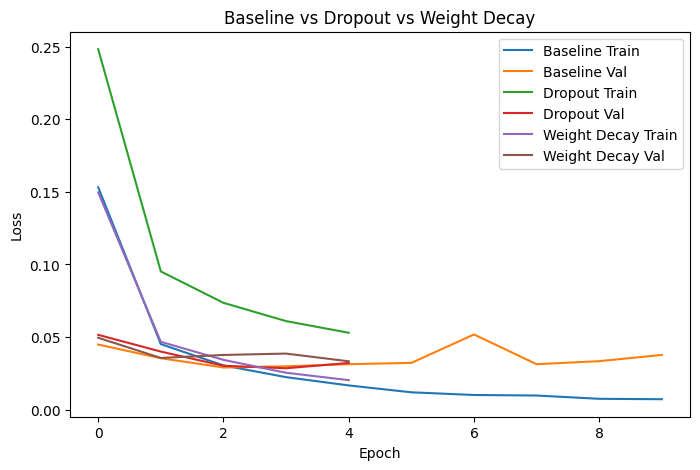

In [4]:
# Your weight decay implementation uses the same model architecture as baseline
# but with weight decay in the optimizer

import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightDecayModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# TODO: Instantiate model with same architecture as baseline
device = "cuda" if torch.cuda.is_available() else "cpu"

wd_model = WeightDecayModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    wd_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4   # <-- L2 regularization
)

num_epochs = 5
train_losses_wd, val_losses_wd = [], []
train_accs_wd, val_accs_wd = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(wd_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(wd_model, val_loader, criterion, device)

    train_losses_wd.append(train_loss)
    val_losses_wd.append(val_loss)
    train_accs_wd.append(train_acc)
    val_accs_wd.append(val_acc)

    print(f"[Weight Decay] Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Baseline Train")
plt.plot(val_losses, label="Baseline Val")
plt.plot(train_losses_d, label="Dropout Train")
plt.plot(val_losses_d, label="Dropout Val")
plt.plot(train_losses_wd, label="Weight Decay Train")
plt.plot(val_losses_wd, label="Weight Decay Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Dropout vs Weight Decay")
plt.legend()
plt.show()

## Task 4: Implement Batch Normalization
**Context:** Batch normalization normalizes the inputs of each layer, which can stabilize and accelerate training by reducing internal covariate shift.

**Steps:**

1. Create a new model that incorporates batch normalization

    - Add `nn.BatchNorm2d` after convolutional layers but before activations
    - Add `nn.BatchNorm1d` for fully connected layers
    - Why might the order of batch norm and activation functions matter?

2. Train the model with batch normalization and evaluate

    - Try using a slightly higher learning rate than before
    - How does batch normalization affect training stability?

3. Compare training speed and final performance with previous models

    - Does batch normalization accelerate convergence?
    - How does it affect the model's generalization ability?

4. Visualize and compare learning curves for all models

    - Which regularization technique had the most significant impact?

Epoch 1: Train Loss=0.0998, Test Loss=0.8191, Acc=79.63%
Epoch 2: Train Loss=0.0352, Test Loss=0.4348, Acc=86.38%
Epoch 3: Train Loss=0.0256, Test Loss=0.4446, Acc=87.10%
Epoch 4: Train Loss=0.0202, Test Loss=0.4721, Acc=84.08%
Epoch 5: Train Loss=0.0181, Test Loss=0.5705, Acc=82.14%


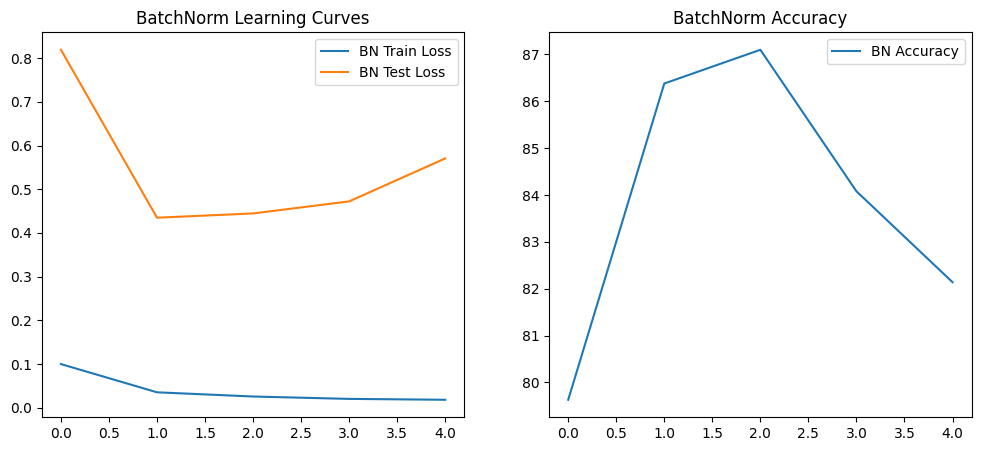

In [6]:
# Your batch normalization model implementation
class BatchNormModel(nn.Module):
    def __init__(self):
        super(BatchNormModel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),  # 14×14

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2, 2)  # 7×7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BatchNormModel().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.002)  # slightly higher LR

train_losses = []
test_losses = []
accuracies = []

epochs=5
for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    accuracies.append(100 * correct / total)

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, "
          f"Test Loss={test_losses[-1]:.4f}, Acc={accuracies[-1]:.2f}%")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="BN Train Loss")
plt.plot(test_losses, label="BN Test Loss")
plt.title("BatchNorm Learning Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(accuracies, label="BN Accuracy")
plt.title("BatchNorm Accuracy")
plt.legend()

plt.show()